In [2]:
import pandas as pd

orders = pd.read_csv("C:/Users/prana/OneDrive/Desktop/E-commerce_Analytcs/data/olist_orders_dataset.csv")
customers = pd.read_csv("../data/olist_customers_dataset.csv")
payments = pd.read_csv("../data/olist_order_payments_dataset.csv")
products = pd.read_csv("../data/olist_products_dataset.csv")
items = pd.read_csv("../data/olist_order_items_dataset.csv")
category_translated = pd.read_csv("../data/product_category_name_translation.csv")


In [3]:
orders_datetime_col = ["order_purchase_timestamp", "order_approved_at",
                       "order_delivered_carrier_date", "order_delivered_customer_date", "order_estimated_delivery_date"]

for col in orders_datetime_col:
    orders[col] = pd.to_datetime(orders[col], errors = "coerce")

In [4]:
orders["purchase_year"] = orders["order_purchase_timestamp"].dt.year
orders["purchase_month"] = orders["order_purchase_timestamp"].dt.month
orders["delivery_days"] = (orders["order_delivered_customer_date"] - orders["order_purchase_timestamp"]).dt.days

In [5]:
products[products["product_category_name"].isnull()].isnull().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                1
product_length_cm               1
product_height_cm               1
product_width_cm                1
dtype: int64

In [6]:
orders_customers = pd.merge(
    orders,
    customers,
    how = "inner",
    on = "customer_id"
)

In [7]:
orders_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   purchase_year                  99441 non-null  int32         
 9   purchase_month                 99441 non-null  int32         
 10  delivery_days                  96476 non-null  float64       
 11  customer_unique

In [8]:
state_orders = orders_customers["customer_state"].value_counts()

((state_orders / state_orders.sum()) * 100).head(10)

customer_state
SP    41.980672
RJ    12.924247
MG    11.700405
RS     5.496727
PR     5.073360
SC     3.657445
BA     3.399000
DF     2.152030
ES     2.044428
GO     2.031355
Name: count, dtype: float64

In [9]:
import matplotlib.pyplot as plt

top_states = state_orders.head(10)

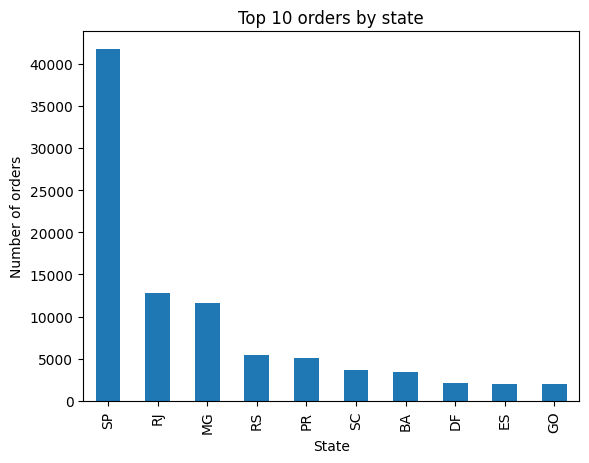

In [10]:
top_states.plot(kind = "bar")

plt.title("Top 10 orders by state")
plt.xlabel("State")
plt.ylabel("Number of orders")
plt.savefig("../charts/top_states_orders.png", bbox_inches = "tight")
plt.show()



In [11]:
top_10_cities = orders_customers["customer_city"].value_counts().head(10)
print((top_10_cities.sum() / len(orders_customers)) * 100)

35.23898593135628


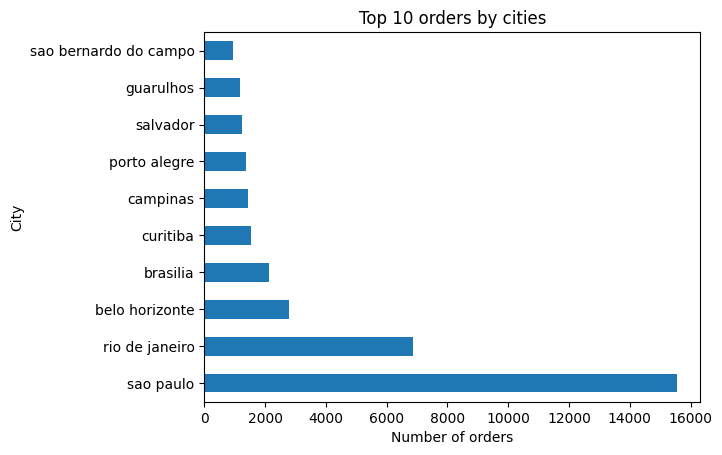

In [12]:
top_10_cities.plot(kind = 'barh')

plt.title("Top 10 orders by cities")
plt.xlabel("Number of orders")
plt.ylabel("City")
plt.savefig("../charts/top_cities_orders.png", bbox_inches = "tight")
plt.show()

In [13]:
monthly_orders = orders.groupby("purchase_month").size()
monthly_orders

purchase_month
1      8069
2      8508
3      9893
4      9343
5     10573
6      9412
7     10318
8     10843
9      4305
10     4959
11     7544
12     5674
dtype: int64

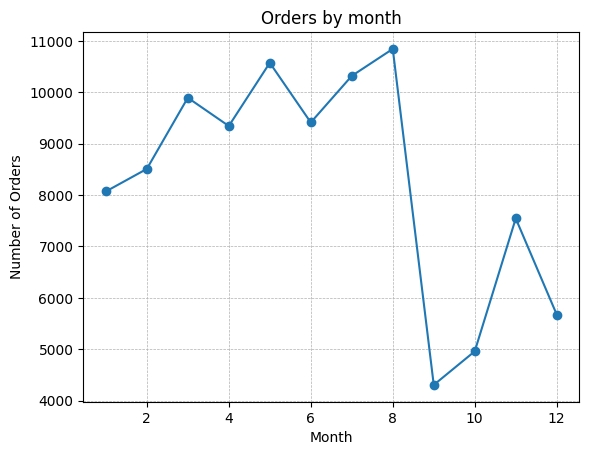

In [14]:
monthly_orders.plot(kind = "line", marker = "o")

plt.title("Orders by month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True, linestyle = "--", linewidth = 0.5)
plt.savefig("../charts/monthly_orders_trend.png")
plt.show()

In [15]:
orders["year_month"] = orders["order_purchase_timestamp"].dt.to_period("M")
orders.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,delivery_days,year_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,8.0,2017-10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,13.0,2018-07
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,9.0,2018-08
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017,11,13.0,2017-11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018,2,2.0,2018-02


In [16]:
monthly_trend = orders.groupby("year_month").size()
monthly_trend

year_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

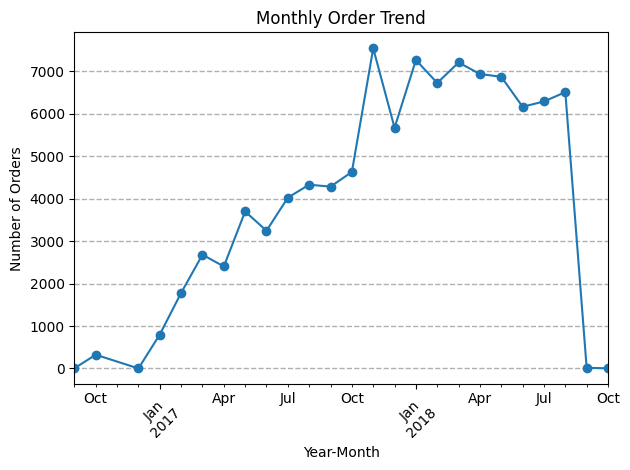

In [17]:
monthly_trend.plot(kind = "line", marker = "o")

plt.title("Monthly Order Trend")
plt.xlabel("Year-Month")
plt.ylabel("Number of Orders")

plt.grid(True, axis = "y", linestyle = "--", linewidth = 1)
plt.xticks(rotation = 45)
plt.tight_layout()

plt.savefig("../charts/monthly_order_timeline.png", bbox_inches = "tight")

plt.show()

In [18]:
orders_payments = pd.merge(
    orders,
    payments,
    how = "inner",
    on = "order_id"
)

orders_payments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 16 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       103886 non-null  object        
 1   customer_id                    103886 non-null  object        
 2   order_status                   103886 non-null  object        
 3   order_purchase_timestamp       103886 non-null  datetime64[ns]
 4   order_approved_at              103711 non-null  datetime64[ns]
 5   order_delivered_carrier_date   101998 non-null  datetime64[ns]
 6   order_delivered_customer_date  100754 non-null  datetime64[ns]
 7   order_estimated_delivery_date  103886 non-null  datetime64[ns]
 8   purchase_year                  103886 non-null  int32         
 9   purchase_month                 103886 non-null  int32         
 10  delivery_days                  100754 non-null  float64       
 11  

In [19]:
print(payments["payment_value"].sum())
print(payments["payment_value"].mean())
payments["payment_value"].describe()

16008872.12
154.10038041699553


count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [20]:
monthly_revenue = orders_payments.groupby("year_month")["payment_value"].sum()
monthly_revenue

year_month
2016-09        252.24
2016-10      59090.48
2016-12         19.62
2017-01     138488.04
2017-02     291908.01
2017-03     449863.60
2017-04     417788.03
2017-05     592918.82
2017-06     511276.38
2017-07     592382.92
2017-08     674396.32
2017-09     727762.45
2017-10     779677.88
2017-11    1194882.80
2017-12     878401.48
2018-01    1115004.18
2018-02     992463.34
2018-03    1159652.12
2018-04    1160785.48
2018-05    1153982.15
2018-06    1023880.50
2018-07    1066540.75
2018-08    1022425.32
2018-09       4439.54
2018-10        589.67
Freq: M, Name: payment_value, dtype: float64

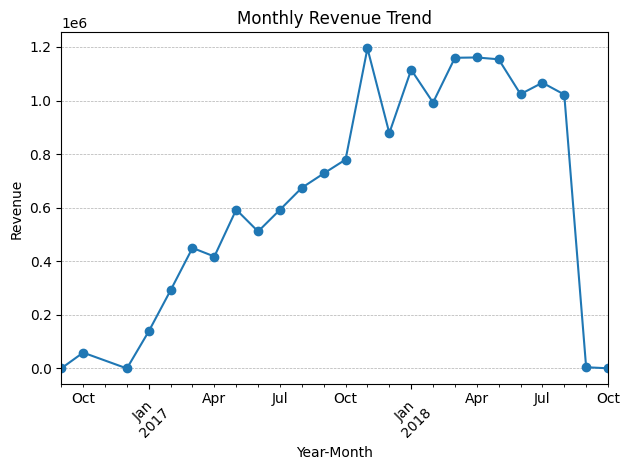

In [21]:
monthly_revenue.plot(kind = "line", marker = "o")

plt.title("Monthly Revenue Trend")
plt.xlabel("Year-Month")
plt.ylabel("Revenue")

plt.grid(True, axis = "y", linestyle = "--", linewidth = 0.5)
plt.xticks(rotation = 45)
plt.tight_layout()

plt.savefig("../charts/monthly_revenue_trend.png", bbox_inches = "tight")

plt.show()

In [22]:
orders_payments["payment_type"].value_counts(normalize = True) * 100

payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

In [23]:
items_products = pd.merge(
    items,
    products,
    how = "left",
    on = "product_id"
)

items_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 15 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   order_id                    112650 non-null  object 
 1   order_item_id               112650 non-null  int64  
 2   product_id                  112650 non-null  object 
 3   seller_id                   112650 non-null  object 
 4   shipping_limit_date         112650 non-null  object 
 5   price                       112650 non-null  float64
 6   freight_value               112650 non-null  float64
 7   product_category_name       111047 non-null  object 
 8   product_name_lenght         111047 non-null  float64
 9   product_description_lenght  111047 non-null  float64
 10  product_photos_qty          111047 non-null  float64
 11  product_weight_g            112632 non-null  float64
 12  product_length_cm           112632 non-null  float64
 13  product_height

In [24]:
items_products_translated = pd.merge(
    items_products,
    category_translated,
    how = "left",
    on = "product_category_name"
)

items_products_translated.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [25]:
top_3_category = items_products_translated["product_category_name_english"].value_counts().head(3)

top_3_category_total_percentage = top_3_category.sum() / len(items_products_translated) * 100

top_3_category_total_percentage

np.float64(26.12161562361296)

In [26]:
category_revenue = items_products_translated.groupby("product_category_name_english")["price"].sum().sort_values(ascending = False)
top_category_revenue = category_revenue.head(10)

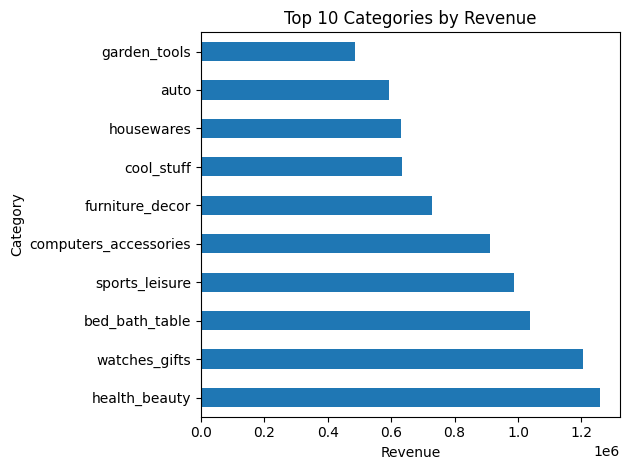

In [27]:
top_category_revenue.plot(kind = "barh")

plt.title("Top 10 Categories by Revenue")
plt.ylabel("Category")
plt.xlabel("Revenue")

plt.tight_layout()

plt.savefig("../charts/top_categories_revenue.png", bbox_inches = "tight")
plt.show()


In [28]:
top_avg_category_price = items_products_translated.groupby("product_category_name_english")["price"].mean().sort_values(ascending = False).head(10)


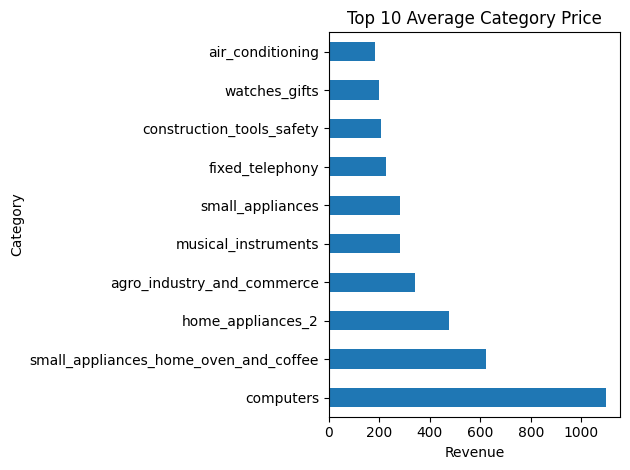

In [29]:
top_avg_category_price.plot(kind = "barh")

plt.title("Top 10 Average Category Price")
plt.ylabel("Category")
plt.xlabel("Revenue")

plt.tight_layout()

plt.savefig("../charts/top_categories_avg_price.png", bbox_inches = "tight")

plt.show()

In [30]:
top_categories_volume = items_products_translated["product_category_name_english"].value_counts().head(10)
top_categories_volume

product_category_name_english
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64

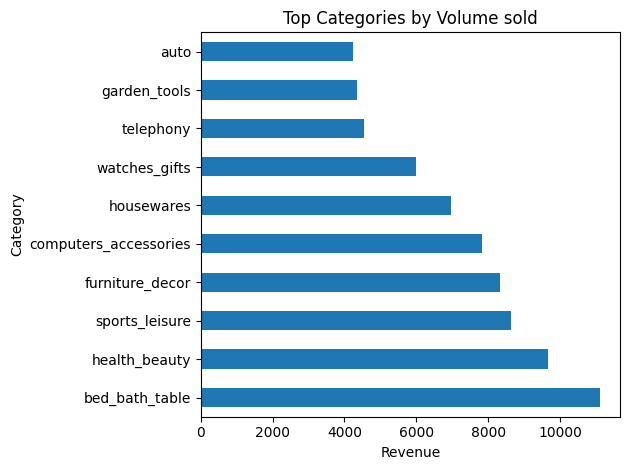

In [31]:
top_categories_volume.plot(kind = "barh")

plt.title("Top Categories by Volume sold")
plt.ylabel("Category")
plt.xlabel("Revenue")

plt.tight_layout()

plt.savefig("../charts/top_categories_volume.png", bbox_inches = "tight")
plt.show()

In [36]:
orders["delivery_delay_days"] = (orders["order_delivered_customer_date"] - orders["order_estimated_delivery_date"]).dt.days

orders["delivery_delay_days"].describe()

count    96476.000000
mean       -11.876881
std         10.183854
min       -147.000000
25%        -17.000000
50%        -12.000000
75%         -7.000000
max        188.000000
Name: delivery_delay_days, dtype: float64

In [ ]:
(orders["delivery_delay_days"] <= 0).mean() * 100

np.float64(90.44659647429128)

In [46]:
state_delivery = orders_customers.groupby("customer_state")["delivery_days"].mean()
state_delivery

customer_state
AC    20.637500
AL    24.040302
AM    25.986207
AP    26.731343
BA    18.866400
CE    20.817826
DF    12.509135
ES    15.331830
GO    15.150741
MA    21.117155
MG    11.543813
MS    15.191155
MT    17.593679
PA    23.316068
PB    19.953578
PE    17.965474
PI    18.993697
PR    11.526711
RJ    14.849186
RN    18.824895
RO    18.913580
RR    28.975610
RS    14.819237
SC    14.479560
SE    21.029851
SP     8.298061
TO    17.226277
Name: delivery_days, dtype: float64

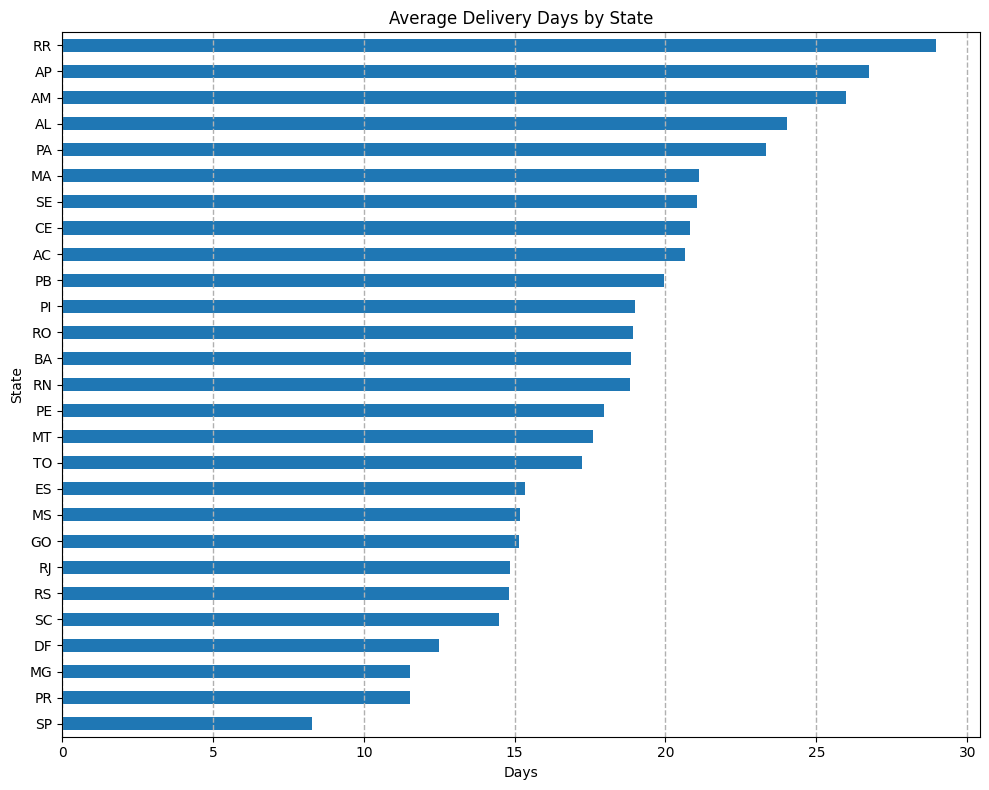

In [55]:
state_delivery.sort_values().plot(kind = "barh", figsize = (10, 8))

plt.title("Average Delivery Days by State")
plt.ylabel("State")
plt.xlabel("Days")
plt.grid(True, axis = "x", linestyle = "--", linewidth = 1)

plt.tight_layout()

plt.savefig("../charts/delivery_days_by_state.png", bbox_inches = "tight")
plt.show()


In [58]:
orders.nlargest(10, "delivery_delay_days")[["order_id",
                                           "delivery_days",
                                           "delivery_delay_days"]]


,order_id,delivery_days,delivery_delay_days
55619,1b3190b2dfa9d789e1f14c05b647a14a,208.0,188.0
19590,ca07593549f1816d26a572e06dc1eab6,209.0,181.0
11399,47b40429ed8cce3aee9199792275433f,191.0,175.0
81401,2fe324febf907e3ea3f2aa9650869fa5,189.0,167.0
89130,285ab9426d6982034523a855f55a885e,194.0,166.0
61610,440d0d17af552815d15a9e41abe49359,195.0,165.0
68769,c27815f7e3dd0b926b58552628481575,187.0,162.0
38509,0f4519c5f1c541ddec9f21b3bddd533a,194.0,161.0
40847,d24e8541128cea179a11a65176e0a96f,175.0,161.0
54480,2d7561026d542c8dbd8f0daeadf67a43,188.0,159.0


In [59]:
orders["delivery_delay_days"].quantile([0.90, 0.95, 0.99])

0.90    -2.0
0.95     3.0
0.99    18.0
Name: delivery_delay_days, dtype: float64

In [66]:
orders_customers.info()
orders_payments.info()
items_products_translated.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
 8   purchase_year                  99441 non-null  int32         
 9   purchase_month                 99441 non-null  int32         
 10  delivery_days                  96476 non-null  float64       
 11  customer_unique